In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
sns.set(style="whitegrid")


In [3]:
city_day = pd.read_csv(r"C:\Users\aasth\OneDrive\Documents\city_day.csv")

In [4]:
city_hour = pd.read_csv(r"C:\Users\aasth\OneDrive\Documents\city_hour.csv")
station_day = pd.read_csv(r"C:\Users\aasth\OneDrive\Documents\station_day.csv")
station_hour = pd.read_csv(r"C:\Users\aasth\OneDrive\Documents\station_hour.csv")
stations = pd.read_csv(r"C:\Users\aasth\OneDrive\Documents\stations.csv")


C:\Users\aasth\AppData\Local\Temp\ipykernel_9152\3407701785.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  station_hour = pd.read_csv(r"C:\Users\aasth\OneDrive\Documents\station_hour.csv")


In [5]:
city_day['Date'] = pd.to_datetime(city_day['Date'])
city_hour['Datetime'] = pd.to_datetime(city_hour['Datetime'])

In [6]:
city_day = city_day.drop_duplicates()
city_hour = city_hour.drop_duplicates()

In [7]:
city_day['Year'] = city_day['Date'].dt.year
city_day['Month'] = city_day['Date'].dt.month

In [8]:
city_hour['Year'] = city_hour['Datetime'].dt.year                            
city_hour['Month'] = city_hour['Datetime'].dt.month                         
city_hour['Hour'] = city_hour['Datetime'].dt.hour

In [9]:
def get_season(month):
    if month in[12,1,2]:
        return "Winter"
    elif month in[3,4,5,6]:
        return "Summer"
    elif month in[7,8,9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"
city_day['Season'] = city_day['Month'].apply(get_season)

In [10]:
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3']
for col in pollutants:
    city_day[col] = city_day[col].fillna(city_day[col].median())

city_day['AQI_Bucket'] = city_day['AQI_Bucket'].fillna("Unknown")

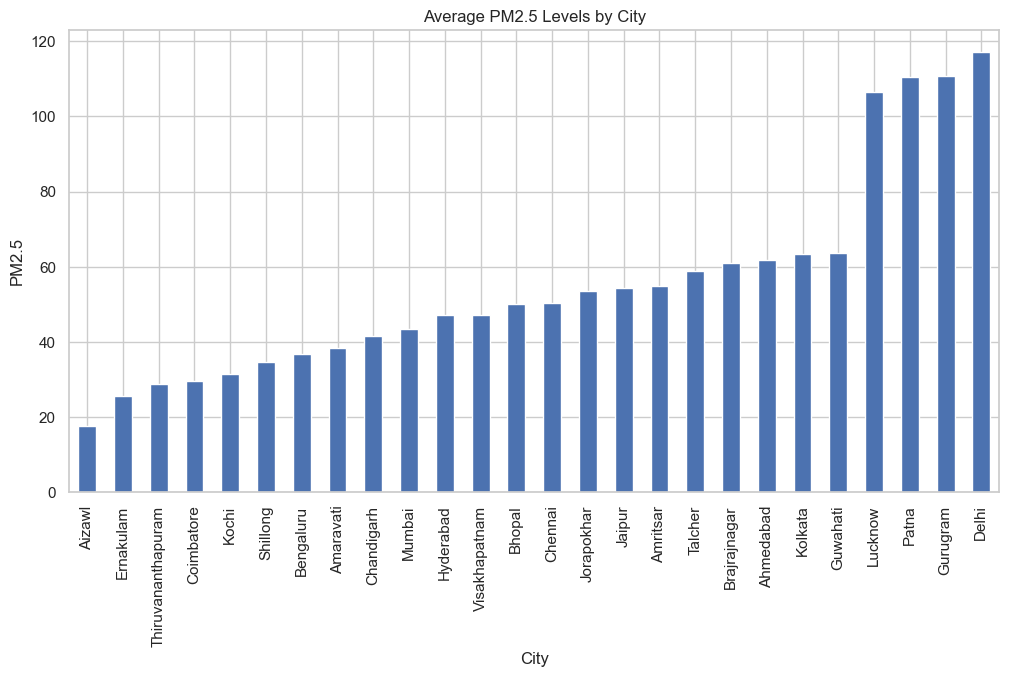

In [11]:
plt.figure(figsize=(12,6))
city_day.groupby('City')['PM2.5'].mean().sort_values().plot(kind='bar')
plt.title("Average PM2.5 Levels by City")
plt.ylabel("PM2.5")
plt.show()

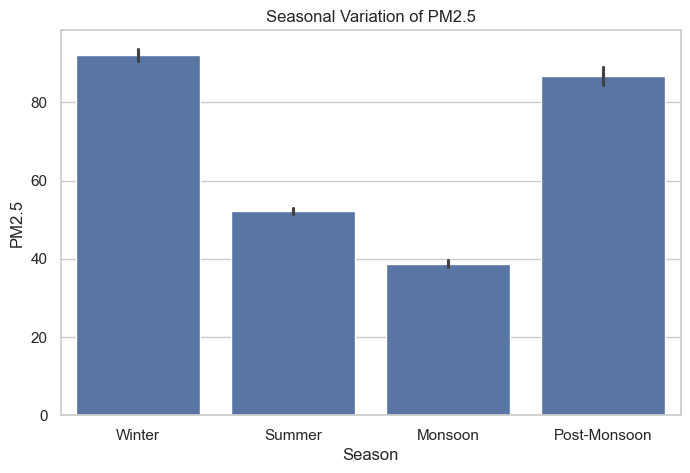

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x='Season', y='PM2.5', data=city_day)
plt.title("Seasonal Variation of PM2.5")
plt.show()

In [13]:
city_pollution = city_day.groupby('City')['PM2.5'].mean().sort_values()
yearly_aqi = city_day.groupby('Year')['AQI'].mean()
season_pollution = city_day.groupby('Season')['PM2.5'].mean()
hourly_pollution = city_hour.groupby('Hour')['PM2.5'].mean()

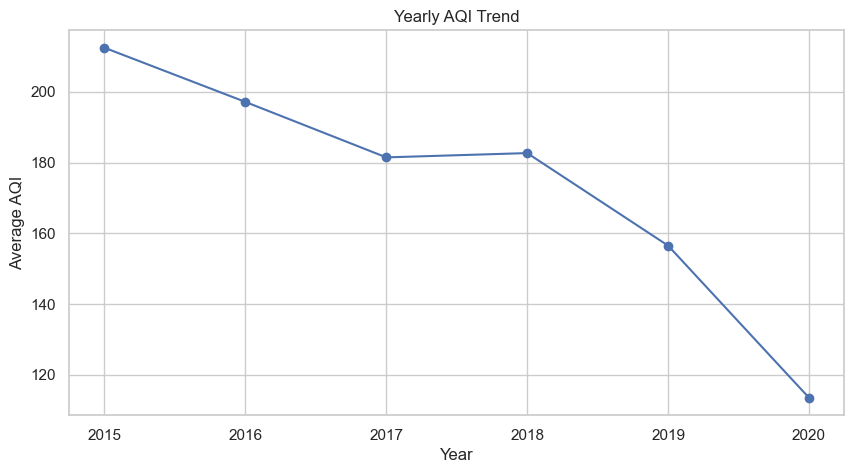

In [14]:
plt.figure(figsize=(10,5))
yearly_aqi.plot(marker='o')
plt.title("Yearly AQI Trend")
plt.ylabel("Average AQI")
plt.show()

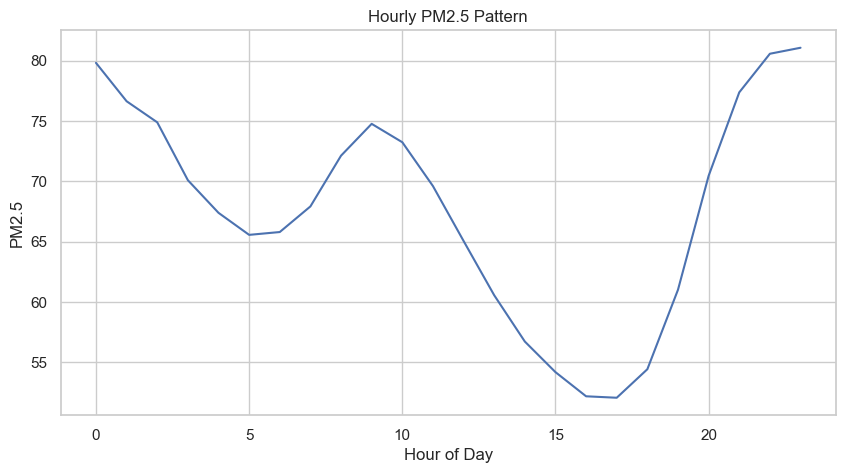

In [15]:
plt.figure(figsize=(10,5))
hourly_pollution.plot()
plt.title("Hourly PM2.5 Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5")
plt.show()

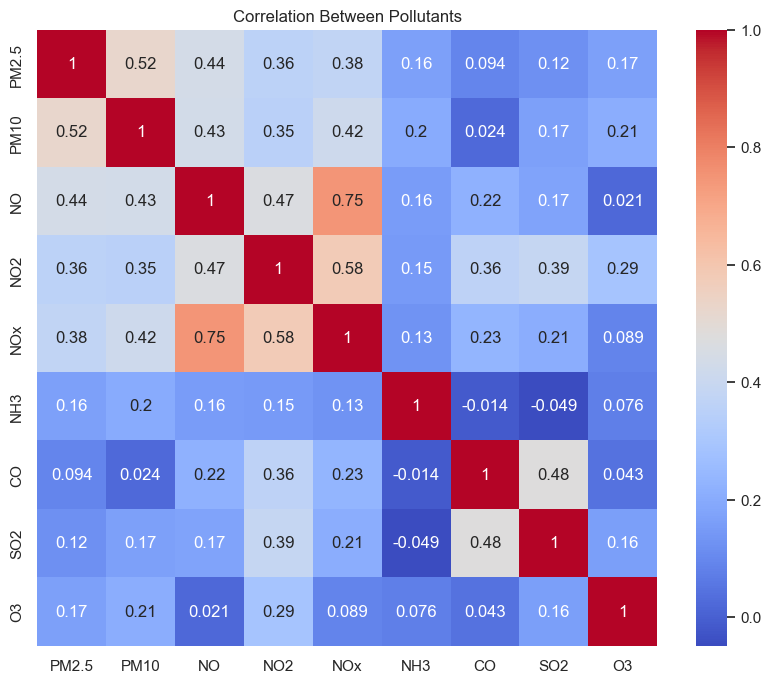

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(city_day[pollutants].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Pollutants")
plt.show()

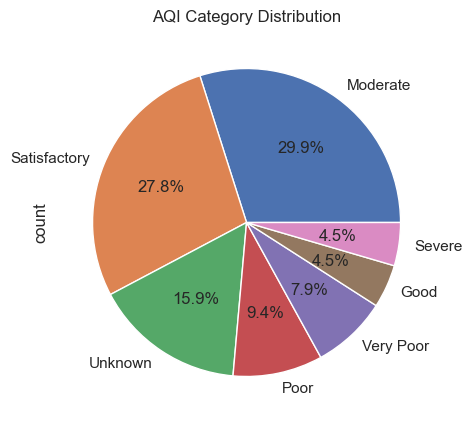

In [17]:
plt.figure(figsize=(8,5))
city_day['AQI_Bucket'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("AQI Category Distribution")
plt.show()

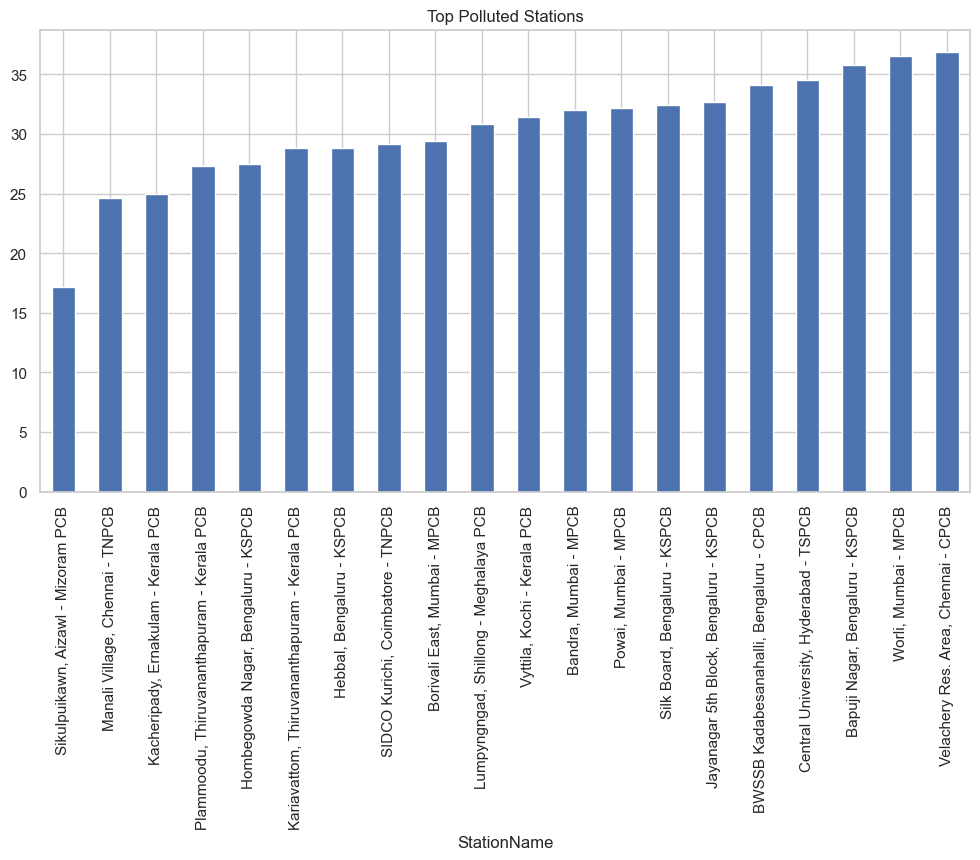

In [18]:
station_data=station_day.merge(stations,on="StationId")
station_pollution=station_data.groupby('StationName')['PM2.5'].mean().sort_values()
plt.figure(figsize=(12,6))
station_pollution.head(20).plot(kind='bar')
plt.title("Top Polluted Stations")
plt.show()

In [19]:
#Machine Learning
city_day = city_day.dropna(subset=['AQI'])

In [20]:
X = city_day[pollutants]
y = city_day['AQI']

# Fill missing values in X
X = X.fillna(X.median())

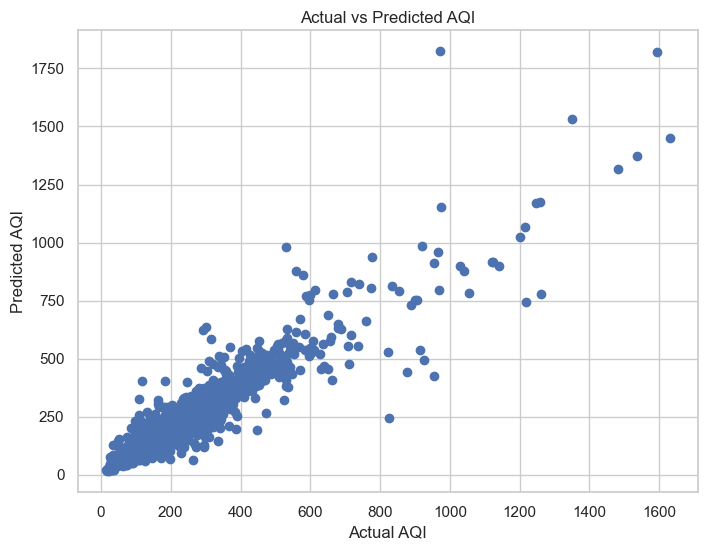

In [22]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()

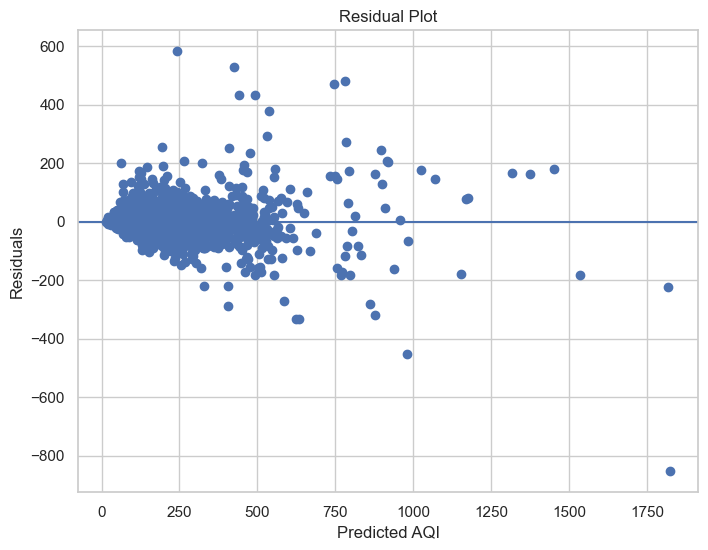

In [23]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [25]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9089056574553598
RMSE: 41.59385990600112


In [30]:
from sklearn.ensemble import RandomForestClassifier

# Remove missing AQI_Bucket
city_day = city_day.dropna(subset=['AQI_Bucket'])

X_cls = city_day[pollutants].fillna(city_day[pollutants].median())
y_cls = city_day['AQI_Bucket']

X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred_cls = clf.predict(X_test)

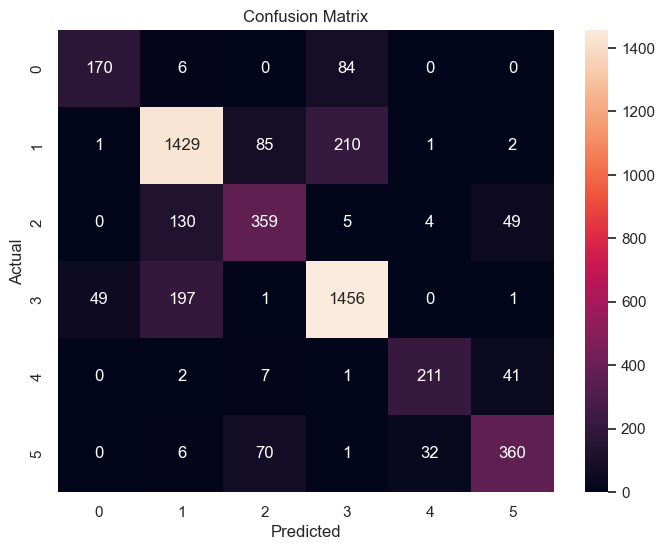

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_cls)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [32]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_cls))

Accuracy: 0.8018108651911469


In [33]:
importance = model.feature_importances_

feat_imp = pd.Series(importance, index=pollutants).sort_values()

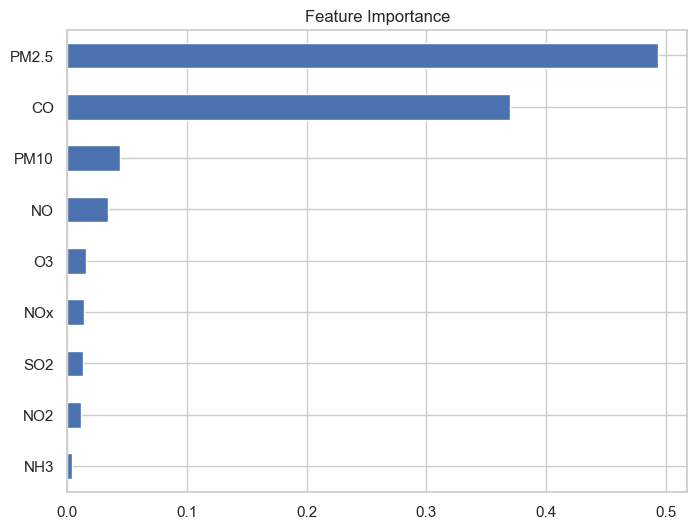

In [34]:
plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

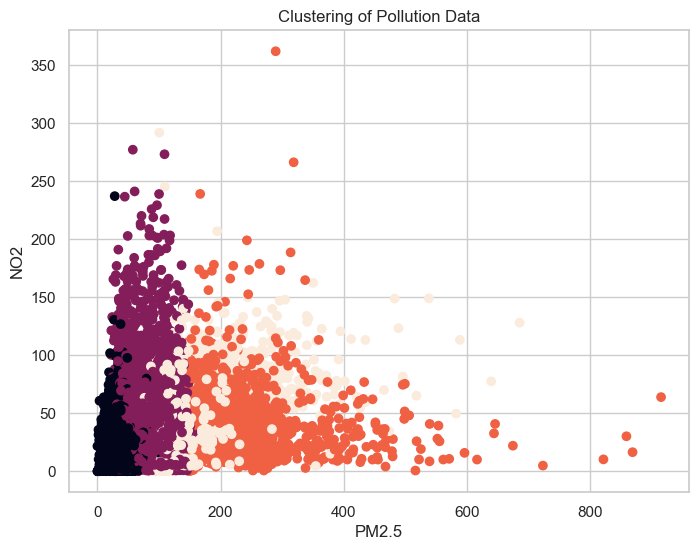

In [35]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
X_cluster = city_day[pollutants].fillna(city_day[pollutants].median())
city_day['Cluster'] = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(8,6))

plt.scatter(city_day['PM2.5'], city_day['NO2'], c=city_day['Cluster'])

plt.xlabel("PM2.5")
plt.ylabel("NO2")
plt.title("Clustering of Pollution Data")

plt.show()

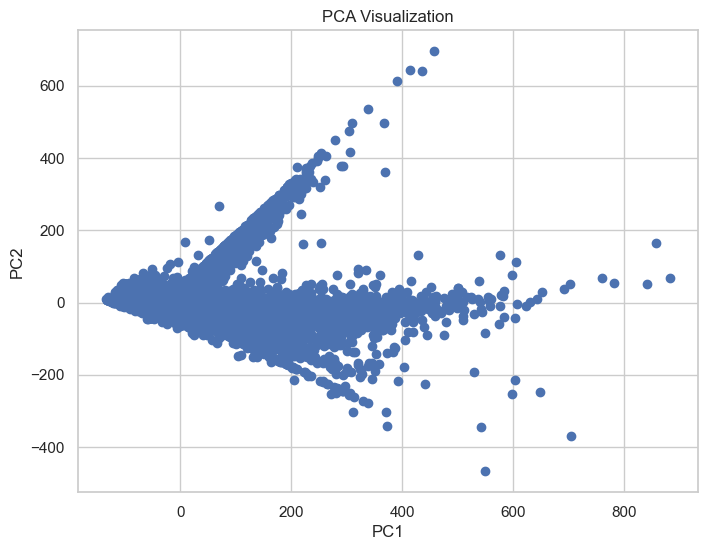

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")

plt.show()

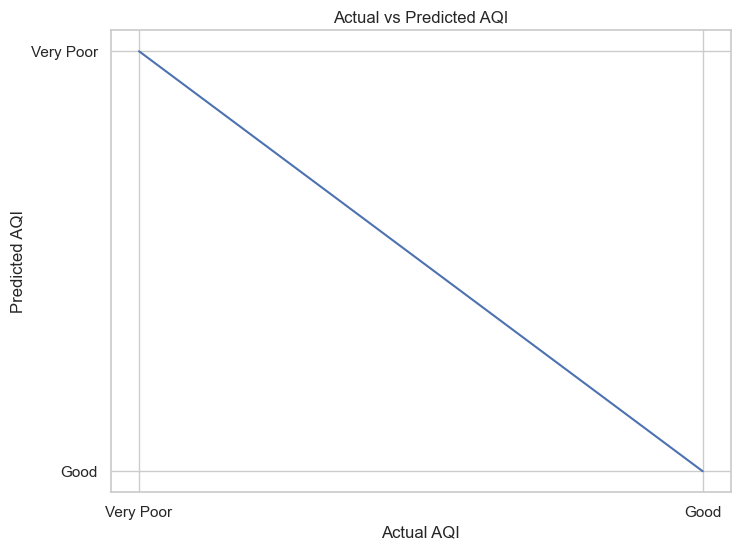

In [37]:
#predictin graphs
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()

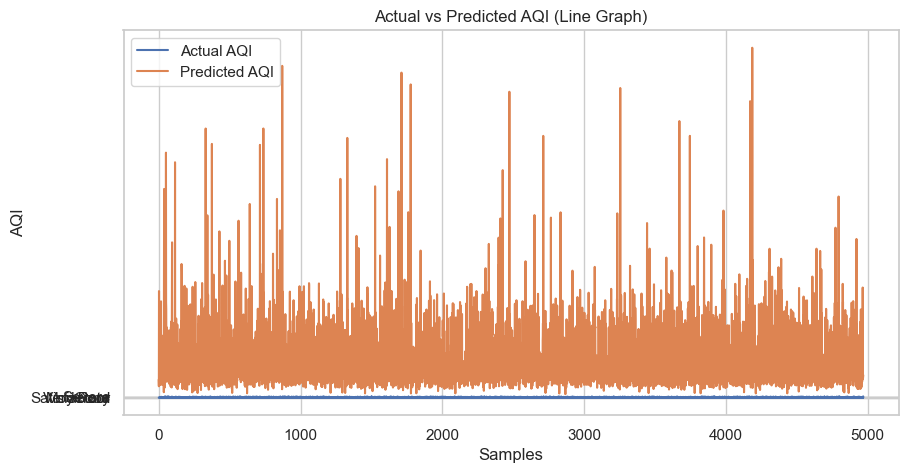

In [38]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual AQI")
plt.plot(y_pred, label="Predicted AQI")

plt.legend()

plt.title("Actual vs Predicted AQI (Line Graph)")
plt.xlabel("Samples")
plt.ylabel("AQI")

plt.show()

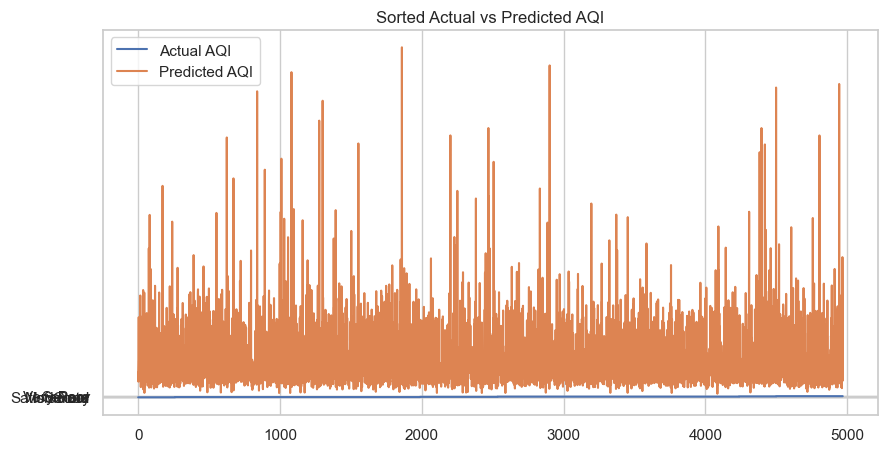

In [39]:
# Sort values for better visualization
sorted_idx = np.argsort(y_test.values)

plt.figure(figsize=(10,5))

plt.plot(y_test.values[sorted_idx], label="Actual AQI")
plt.plot(y_pred[sorted_idx], label="Predicted AQI")

plt.legend()
plt.title("Sorted Actual vs Predicted AQI")

plt.show()

In [1]:
#judging by: By how close the points are to the diagonal line in the scatter plot and how closely the lines overlap in the line graph.